filtered_x [4032 4033 4034 4035 4036 4037 4038 4039 4040 4041 4042 4043 4044 4045
 4046 4047 4048 4049 4050 4051 4052 4053 4054 4055 4056 4057 4058 4059
 4060 4061 4062 4063 4064 4065 4066 4067 4068 4069 4070 4071 4072 4073
 4074 4075 4076 4077 4078 4079 4080 4081 4082 4083 4084 4085 4086 4087
 4088 4089 4090 4091 4092 4093 4094 4095]


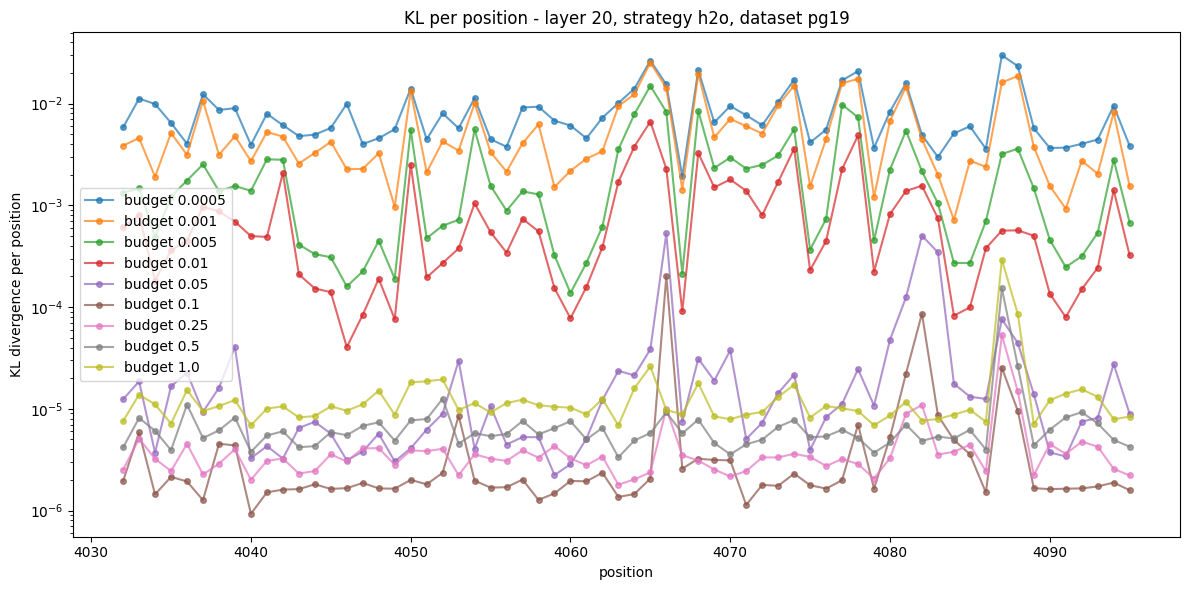

In [26]:
import re

import torch
dataset_name = "pg19"

layer_idx = 20
# head_idx = [0] # [0,...,31]
pos_list = list(range(4096-64, 4096))
strategy = "h2o"
result = torch.load(f"../result/layer{layer_idx}/{dataset_name}/{strategy}/result.pt")

import matplotlib.pyplot as plt
import numpy as np
budgets = [0.0005,0.001, 0.005 ,0.01 , 0.05, 0.1, 0.25, 0.5, 1.0]

plt.figure(figsize=(12,6))

x = np.array(pos_list)  # positions
all_losses = []
for j, budget in enumerate(budgets):
    alpha, p_alpha, p_teacher, loss = result[budget]
    eps = 1e-12
    logp_teacher = torch.log(p_teacher + eps)
    loss_per_pos = (p_teacher * (logp_teacher - torch.log(p_alpha + eps))).sum(dim=-1).detach()  # [n_pos]
    y = loss_per_pos.float().cpu().numpy()
    all_losses.append(y)
max_loss_per_pos = np.max(all_losses, axis=0)
threshold = 1e-8
mask = max_loss_per_pos > threshold 
filtered_x = np.array(pos_list)[mask]
print("filtered_x", filtered_x)
for j, budget in enumerate(budgets):
    filtered_y = all_losses[j][mask]
    
    plt.plot(filtered_x, filtered_y, 'o-', alpha=0.7, markersize=4, label=f"budget {budget}")
plt.xlabel("position")
plt.ylabel("KL divergence per position")
plt.yscale("log")  # 你之前用 log，这里也保留；不需要可删
plt.title(f"KL per position - layer {layer_idx}, strategy {strategy}, dataset {dataset_name}")
plt.legend()
plt.tight_layout()
plt.show()

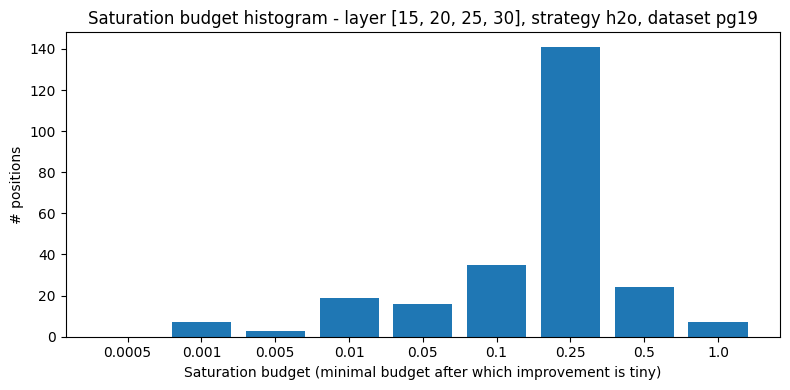

Counts: {0.0005: np.int64(0), 0.001: np.int64(7), 0.005: np.int64(3), 0.01: np.int64(19), 0.05: np.int64(16), 0.1: np.int64(35), 0.25: np.int64(141), 0.5: np.int64(24), 1.0: np.int64(7)}


In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
layer_idx_list = [15, 20, 25, 30]
sat_budget = []
for layer_idx in layer_idx_list:
    result = torch.load(f"../result/layer{layer_idx}/{dataset_name}/{strategy}/result.pt")
    # ---- inputs ----
    budgets = [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0]   # must be increasing

    # ---- compute KL per pos for each budget ----
    all_losses = []
    for budget in budgets:
        alpha, p_alpha, p_teacher, loss = result[budget]
        eps = 1e-12
        kl_per_pos = (p_teacher * (torch.log(p_teacher + eps) - torch.log(p_alpha + eps))).sum(dim=-1)  # [n_pos]
        all_losses.append(kl_per_pos.detach().cpu().float().numpy())

    L = np.stack(all_losses, axis=0)   # [n_budget, n_pos]
    n_budget, n_pos = L.shape

    # Optional: filter positions that are always ~0 (you already do something similar)
    # max_loss_per_pos = L.max(axis=0)
    # mask = max_loss_per_pos > 1e-8     # adjust if needed
    # L = L[:, mask]
    # filtered_pos = np.array(pos_list)[mask]

    find = False
    for p in range(L.shape[1]-1):
        # walk budgets from small -> large; find first place where improvement becomes tiny
        find = False
        for i in range(n_budget - 1):
            Li = L[i, p]
            Lj = L[i + 1, p]
            delta = Li - Lj
            if delta < 1e-7:  # adjust threshold if needed
                sat_budget.append(budgets[i+1])  # minimal budget entering the plateau
                find = True
                break
        if not find:
            sat_budget.append(budgets[-1])  # if never saturated, assign max budget
sat_budget = np.array(sat_budget)
# ---- histogram counts over budgets ----
# Count exact matches to the budget grid
budget_to_idx = {b: k for k, b in enumerate(budgets)}
counts = np.zeros(len(budgets), dtype=int)
for b in sat_budget:
    counts[budget_to_idx[float(b)]] += 1

# ---- plot ----
plt.figure(figsize=(8,4))
plt.bar([str(b) for b in budgets], counts)
plt.xlabel("Saturation budget (minimal budget after which improvement is tiny)")
plt.ylabel("# positions")
plt.title(f"Saturation budget histogram - layer {layer_idx_list}, strategy {strategy}, dataset {dataset_name}")
plt.tight_layout()
plt.show()

print("Counts:", dict(zip(budgets, counts)))

In [25]:
import numpy as np
import torch
import matplotlib.pyplot as plt
layer_idx_list = [20]
sat_budget = []
strategy = "attention_topk"
for layer_idx in layer_idx_list:
    result = torch.load(f"../result/layer{layer_idx}/{dataset_name}/{strategy}/result.pt")
    # ---- inputs ----
    budgets = [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0]   # must be increasing

    # ---- compute KL per pos for each budget ----
    all_losses = []
    for budget in budgets:
        alpha, p_alpha, p_teacher, loss = result[budget]
        eps = 1e-12
        kl_per_pos = (p_teacher * (torch.log(p_teacher + eps) - torch.log(p_alpha + eps))).sum(dim=-1)  # [n_pos]
        all_losses.append(kl_per_pos.detach().cpu().float().numpy())

    L = np.stack(all_losses, axis=0)   # [n_budget, n_pos]
    n_budget, n_pos = L.shape

    a=[]
    find = False
    for p in range(L.shape[1]-1):
        # walk budgets from small -> large; find first place where improvement becomes tiny
        find = False
        for i in range(n_budget - 1):
            Li = L[i, p]
            Lj = L[i + 1, p]
            delta = Li - Lj
            if delta < 1e-7:  # adjust threshold if needed
                sat_budget.append(budgets[i+1])  # minimal budget entering the plateau
                a.append((p, budgets[i+1]))
                find = True
                break
        if not find:
            sat_budget.append(budgets[-1])  # if never saturated, assign max budget
            a.append((p, budgets[-1]))
    a = sorted(a, key=lambda item: item[1])
    print(a[-10:])
sat_budget = np.array(sat_budget)
# ---- histogram counts over budgets ----
# Count exact matches to the budget grid
budget_to_idx = {b: k for k, b in enumerate(budgets)}
counts = np.zeros(len(budgets), dtype=int)
for b in sat_budget:
    counts[budget_to_idx[float(b)]] += 1

[(58, 0.1), (59, 0.1), (60, 0.1), (61, 0.1), (62, 0.1), (8, 0.25), (45, 0.25), (47, 0.25), (54, 0.25), (55, 0.25)]
